<a href="https://colab.research.google.com/github/chaimoma/D-tection-d-motions-Faciales/blob/main/cnn_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip -oq sample_data/archive.zip

In [2]:
!ls

sample_data  test  train


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


In [4]:
#  Model & Image Settings
image_height = 48
image_width = 48
batch_size = 32
color_mode = 'grayscale'
input_shape = (image_height, image_width, 1) # 1 channel for grayscale

# Data Paths
train_dir = 'train'
test_dir = 'test'

In [5]:
## load train data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='categorical', # Labels will be one hot encoded
    seed=123,
    image_size=(image_height,image_width),
    color_mode=color_mode,
    batch_size=batch_size
)

##load validation (test) data
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode='categorical',
    seed=123,
    image_size=(image_height,image_width),
    color_mode=color_mode,
    batch_size=batch_size
)

class_names=train_ds.class_names
num_classes=len(class_names)
print (f"\nFound {num_classes} classes: {class_names}")

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.

Found 7 classes: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Displaying a sample of training images...


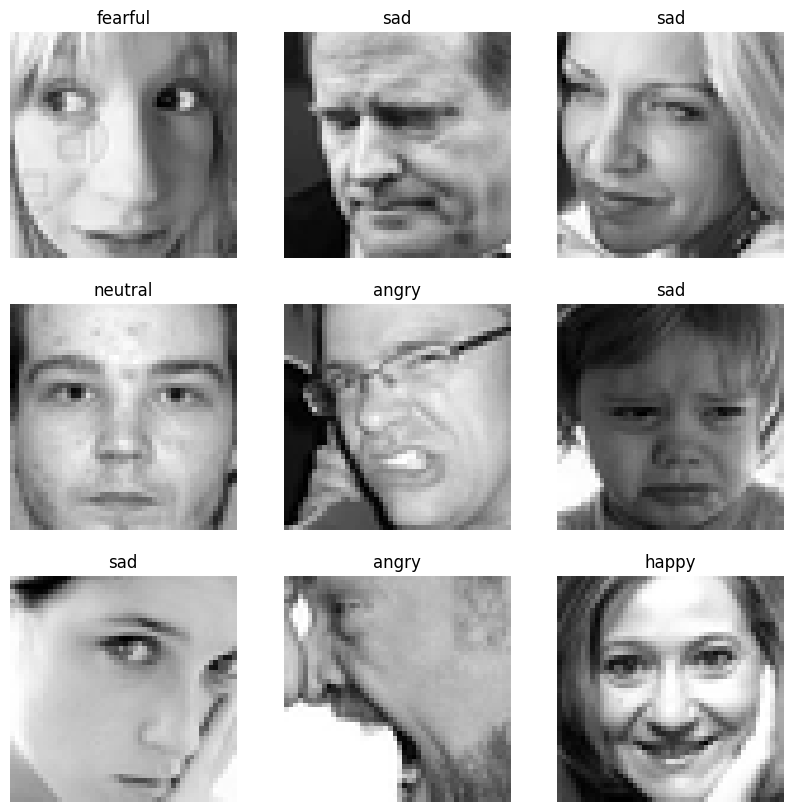

In [7]:
import numpy as np

print("Displaying a sample of training images...")

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):  # Takes one batch
    for i in range(9):  # Plot the first 9
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")


        # Convert the one-hot vector (e.g., [0,0,1,0...]) back to an index (e.g., 2)
        label_index = np.argmax(labels[i])
        plt.title(class_names[label_index])

        plt.axis("off")

plt.show()

In [8]:
# This creates a small "pre-model" for augmentation
data_augmentation = tf.keras.Sequential(
  [
    layers.RandomFlip("horizontal", input_shape=input_shape),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model = models.Sequential([
    data_augmentation,
     #normalization layer (It slides 32 different "filters"across the image.Each filter is tiny(3×3 pixels)and is trained to find a specific, simple feature (like a tiny edge or a curve)
    layers.Rescaling(1./255, input_shape=input_shape),
    #This is the first Convolutional Layer(eyes)
    layers.Conv2D(32,(3,3),activation='relu'),
    #It shrinks the image (by half, usually). It takes a 2×2 square of pixels and keeps only the maximum (strongest) value
    #it helps the model focus in the important features
    layers.MaxPooling2D(),

    #The second block of "eyes."
    #This is the same as the first block, but with 64 filters. Because it's working on the shrunk output of the first block, it can now find more complex features by combining the simple ones (e.g., combining two edges to find a "corner")
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    #The third block of "eyes."
    #Same idea, but now with 128 filters. It's looking for even more complex features (e.g., combining a corner and a curve to find "part of an eye").
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    #During training, this layer randomly "turns off" 25% of the neurons. This sounds crazy, but it forces the model to learn multiple ways to find an emotion, preventing it from just "memorizing" the training images (this is called overfitting).
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),#Dense Layer, the first part of the "brain"

    layers.Dense(num_classes, activation='softmax') #The Final Output Layer (the "mouth").
])

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopper = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [12]:
epochs = 50
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=epochs,
    callbacks=[early_stopper])

Epoch 1/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.2581 - loss: 1.7876 - val_accuracy: 0.3897 - val_loss: 1.5885
Epoch 2/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.3665 - loss: 1.6201 - val_accuracy: 0.4572 - val_loss: 1.4139
Epoch 3/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.4258 - loss: 1.4857 - val_accuracy: 0.4880 - val_loss: 1.3426
Epoch 4/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.4599 - loss: 1.4086 - val_accuracy: 0.5052 - val_loss: 1.2962
Epoch 5/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.4762 - loss: 1.3727 - val_accuracy: 0.5029 - val_loss: 1.2846
Epoch 6/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.4902 - loss: 1.3256 - val_accuracy: 0.5148 - val_loss: 1.2495
Epoch 7/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.4972 - loss: 1.3053 - val_accuracy: 0.5286 - val_loss: 1.2261
Epoch 8/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.5078 - loss: 1.2923 - 

In [13]:

# 1. Get one batch of test images and labels
for test_images, test_labels in test_ds.take(1):

    # 2. Make predictions on that batch
    predictions = model.predict(test_images)

    print("--- Displaying 5 Test Predictions ---")

    # 3. Loop through the first 5 images in the batch
    for i in range(5):

        # --- Get the Predicted label ---
        # np.argmax finds the index of the highest probability
        predicted_index = np.argmax(predictions[i])
        predicted_class = class_names[predicted_index]

        # --- Get the Actual (True) label ---
        actual_index = np.argmax(test_labels[i])
        actual_class = class_names[actual_index]

        # 4. Print the result
        print(f"Image #{i+1} - Actual: {actual_class}, Predicted: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
--- Displaying 5 Test Predictions ---
Image #1 - Actual: disgusted, Predicted: disgusted
Image #2 - Actual: neutral, Predicted: neutral
Image #3 - Actual: angry, Predicted: neutral
Image #4 - Actual: happy, Predicted: happy
Image #5 - Actual: angry, Predicted: happy


In [14]:
model.save('saved_model/emotion_model.h5')

In [15]:
from google.colab import files
files.download('saved_model/emotion_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>